# Retail Sales Analytics 

## Project Overview

This project analyzes retail sales transactions using MySQL, SQL analytics, Python, and pandas to identify customer behavior, product performance, regional sales trends, and business KPIs.

Import Required Libraries 


In [20]:
import pandas as pd
import mysql.connector

Connect MySQL Database to Python

In [21]:

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="retail_sales"
)

print("Connected Successfully")

Connected Successfully


Load SQL Table into pandas DataFrame

In [6]:
query = "SELECT * FROM store"

df = pd.read_sql(query, conn)

print(df.head())

   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2016-152156  2016-11-08  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  10/18/2015  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal_Code  Region       Product_ID         Category Sub_Category  \
0       42420   Sout

C:\Users\91815\AppData\Local\Temp\ipykernel_12096\543156339.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


 Dataset Overview and Structure

In [7]:
print(df.shape)

print(df.columns)

print(df.info())


(9694, 21)
Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 9694 entries, 0 to 9693
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9694 non-null   int64  
 1   Order_ID       9694 non-null   str    
 2   Order_Date     9694 non-null   object 
 3   Ship_Date      9694 non-null   str    
 4   Ship_Mode      9694 non-null   str    
 5   Customer_ID    9694 non-null   str    
 6   Customer_Name  9694 non-null   str    
 7   Segment        9694 non-null   str    
 8   Country        9694 non-null   str    
 9   City           9694 non-null   str    
 10  State          9694 non-null   str    
 11  Postal_Co

Missing Value Analysis

In [8]:
print(df.isnull().sum())

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Revenue and Profit KPI Analysis

In [9]:
total_revenue = df['Sales'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 2272449.8563


In [10]:
total_profit = df['Profit'].sum()

print("Total Profit:", total_profit)

Total Profit: 282857.7542


Regional Sales Analysis

region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

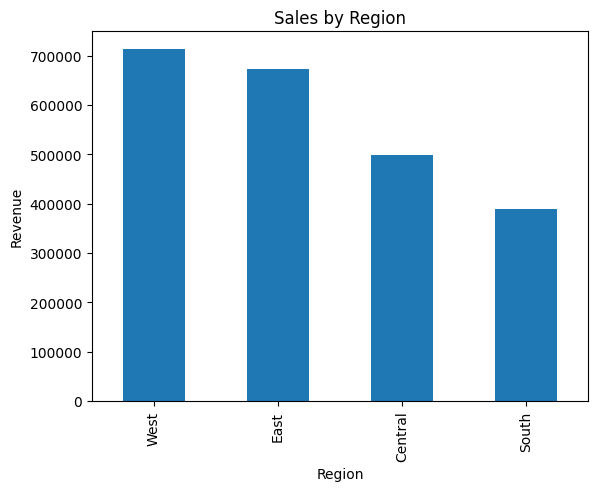

In [12]:
import matplotlib.pyplot as plt

region_sales.plot(kind='bar')

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.show()

Monthly Sales Trend Analysis

In [14]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

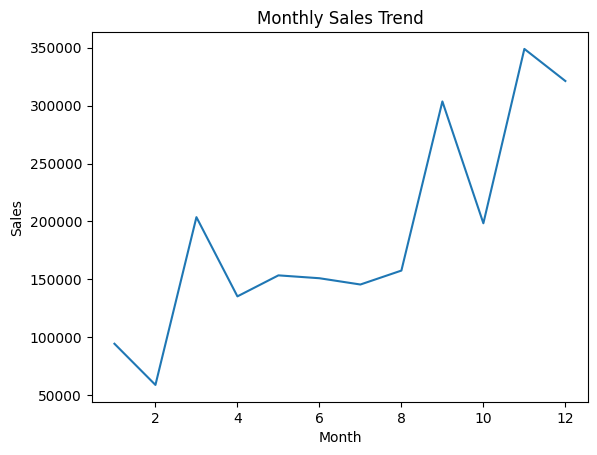

In [15]:
monthly_sales = (
    df.groupby(
        df['Order_Date'].dt.month
    )['Sales']
    .sum()
)

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [16]:
category_profit = (
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         145387.0966
Office Supplies    120489.8864
Furniture           16980.7712
Name: Profit, dtype: float64


In [17]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

print(corr)

               Row_ID  Postal_Code     Sales  Quantity  Discount    Profit
Row_ID       1.000000     0.011240 -0.001163 -0.003537  0.011074  0.012761
Postal_Code  0.011240     1.000000 -0.025184  0.009438  0.064032 -0.030880
Sales       -0.001163    -0.025184  1.000000  0.202009 -0.025969  0.479158
Quantity    -0.003537     0.009438  0.202009  1.000000  0.004706  0.066830
Discount     0.011074     0.064032 -0.025969  0.004706  1.000000 -0.221510
Profit       0.012761    -0.030880  0.479158  0.066830 -0.221510  1.000000


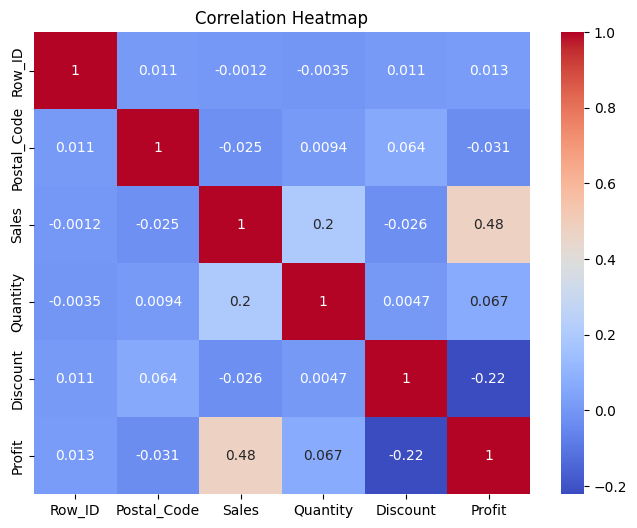

In [18]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Business Insights and Recommendations

*West region generates highest revenue
*Discounts negatively impact profit margins
*Technology category shows highest profitability
*A small percentage of customers contribute major sales


Conclusion

The analysis identified major revenue drivers, profitable product categories, customer purchasing patterns, and regional business trends that can support data-driven retail decision making.